# Detector de Imágenes Generadas por IA vs. Imágenes Reales

## Técnicas de Aprendizaje de Máquina — Proyecto de Aplicación 2

### Pontificia Universidad Javeriana

| | |
|---|---|
| **Dataset** | `Parveshiiii/AI-vs-Real` (HuggingFace) |
| **Problema** | Clasificación Binaria: IA vs. Real |
| **Modelos** | CNN desde cero · EfficientNetB0 (Transfer Learning) · Vision Transformer |
| **Aplicación Web** | Gradio → HuggingFace Spaces |

**Autores:**  
* Catalina Polo Pachón
* Ricardo Andres Hurtado
* [Integrante 3]  
* Javier Felipe Aldana Jaramillo

**Fecha:** Mayo 2026

---
## 0. Instalación e Importación de Librerías

In [2]:
# ── Instalación de dependencias (ejecutar en Google Colab) ───────────────
!pip install datasets transformers timm gradio scikit-learn matplotlib seaborn Pillow -q

In [3]:
import os
import random
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from PIL import Image
from datasets import load_dataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Reproducibilidad ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Estilo de gráficos ───────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

LABEL_MAP = {0: 'IA-Generada', 1: 'Real'}
IMG_SIZE  = 64    # px × px — reducido a 64 para evitar OOM en ejecución local

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print('Librerías importadas correctamente ✓')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Librerías importadas correctamente ✓


## 1. Contexto de la problemática

### 1.1 Preguntas de negocio
- ¿Es posible determinar automáticamente si una imagen fue generada por IA o capturada del mundo real?

- ¿Qué características visuales (texturas, bordes, patrones de ruido) diferencian mejor a las imágenes sintéticas de las reales?

- ¿Qué arquitectura de Deep Learning logra el mayor rendimiento en esta tarea de clasificación binaria, considerando precisión y costo computacional?

- ¿Puede un modelo ligero basado en Transfer Learning superar a una CNN entrenada desde cero sobre los mismos datos?



### 1.2 Justificación

Los modelos generativos de imágenes basados en inteligencia artificial (como Stable Diffusion,
Midjourney y DALL-E) han alcanzado un nivel de realismo que hace prácticamente imposible
la distinción visual por parte de un observador humano no entrenado. Un estudio de 2024
publicado en *Psychological Science* (Nightingale & Farid, 2024) demostró que los participantes
identificaron correctamente las imágenes generadas por IA apenas el 61% de las veces, apenas
por encima del azar.

Este fenómeno tiene consecuencias directas y documentadas en múltiples ámbitos:

- Desinformación y manipulación electoral: El MIT Media Lab reportó en 2023 un incremento
  del 400% en la circulación de imágenes sintéticas relacionadas con eventos políticos en el
  período previo a elecciones nacionales en distintos países. La empresa de verificación
  NewsGuard identificó más de 700 sitios web operando con contenido generado por IA sin
  etiquetado alguno (NewsGuard, 2024).

- Fraude de identidad y suplantación: El FBI emitió en 2023 una alerta pública sobre el uso
  creciente de imágenes y videos deepfake para evadir sistemas de verificación de identidad en
  procesos de contratación remota y acceso a servicios financieros (FBI, IC3 Report, 2023).

- Vulneración de derechos de autor: La Oficina de Derechos de Autor de EE.UU. abrió en
  2023 una consulta pública formal sobre el estatus legal de imágenes generadas por IA que
  imitan estilos de artistas sin consentimiento (U.S. Copyright Office, 2023).

Si bien existen iniciativas de marcado de origen como el estándar **C2PA** (*Coalition for Content
Provenance and Authenticity*), adoptado parcialmente por Adobe, Microsoft y Google, estos
mecanismos dependen de metadatos que son eliminados fácilmente al momento de compartir
imágenes en redes sociales o al realizar capturas de pantalla. Google DeepMind ha propuesto
**SynthID** como alternativa de marca de agua imperceptible (Lim et al., 2024), pero su adopción
sigue siendo limitada y no universal.

En este contexto, la detección automática basada en características visuales aprendidas
representa una línea de defensa independiente y escalable, con aplicabilidad directa en
plataformas de contenido, agencias de verificación (*fact-checking*) y sistemas de seguridad.

### 1.3 ¿Por qué este proyecto es relevante?
"En 2026, cualquier imagen puede ser falsa. La diferencia entre una foto real y una generada
por inteligencia artificial ya no es visible al ojo humano — pero sí es detectable por un modelo
bien entrenado. Nosotros construimos ese detector: un sistema capaz de clasificar imágenes
reales versus sintéticas en menos de un segundo, entrenado sobre miles de ejemplos reales,
y evaluado con rigor académico bajo múltiples arquitecturas de Deep Learning."

*Mercado objetivo:*
- Plataformas de redes sociales (moderación automatizada de contenido)
- Medios de comunicación y agencias de *fact-checking*
- Organismos electorales y de supervisión democrática
- Sistemas de verificación de identidad biométrica
- Plataformas de comercio electrónico (detección de imágenes de producto falsas)

**Tipo de problema:** Clasificación binaria supervisada — `real` vs. `ai-generated`

**Dataset:** [`alessiocorrado99/AI-generated-vs-Real-Images-Datasets`](https://huggingface.co/datasets/alessiocorrado99/AI-generated-vs-Real-Images-Datasets)
disponible en HuggingFace Datasets, con imágenes etiquetadas de ambas clases.

---

#### Referencias
- Nightingale, S. J., & Farid, H. (2024). AI-generated faces are indistinguishable from real faces
  and more trustworthy. *Psychological Science*.
- FBI Internet Crime Complaint Center. (2023). *IC3 Annual Report 2023*. U.S. Department of Justice.
- NewsGuard. (2024). *The AI Misinformation Monitor*. NewsGuard Technologies.
- U.S. Copyright Office. (2023). *Copyright and Artificial Intelligence: Public Consultation*.
  Library of Congress.
- Lim, S., et al. (2024). SynthID: Robust watermarking for AI-generated images. *Google DeepMind
  Technical Report*.
- C2PA. (2023). *Content Credentials: An open technical standard for content provenance*.
  Coalition for Content Provenance and Authenticity.

## 2. Diccionario y Justificación de Datos

### 2.1 Dataset Principal: `Parveshiiii/AI-vs-Real`

**Fuente:** https://huggingface.co/datasets/Parveshiiii/AI-vs-Real  
**Tipo de dato:** No estructurado — Imágenes (RGB, formato JPEG/PNG)  
**Tamaño total:** 13 999 imágenes · 2.16 GB  
**Split original:** `train` único (subdividido manualmente con estratificación)

El dataset reúne imágenes de dos categorías mutuamente excluyentes: imágenes fotografiadas
del mundo real e imágenes sintetizadas mediante modelos generativos de IA (principalmente
Stable Diffusion y Midjourney). Su estructura binaria lo hace directamente adecuado para
un problema de clasificación supervisada.

#### Tabla Diccionario de Campos

| Campo | Tipo | Descripción |
|-------|------|-------------|
| `image` | `PIL.Image` / `bytes` | Imagen en formato RGB (JPEG/PNG), resolución variable según muestra |
| `label` | `int` (0 ó 1) | Etiqueta de clase: `0 = AI-Generada` · `1 = Real` |

> *Nota sobre convención de etiquetas:* el dataset asigna la clase positiva 1 a imágenes
> reales. Esta convención se mantiene a lo largo de todo el proyecto para garantizar coherencia
> en la interpretación de métricas. Al reportar Precision y Recall, la clase de interés primario
> es 0 (IA-Generada), pues corresponde al caso que se desea detectar.


### 2.2 Justificación de Selección del Dataset

Durante la fase de exploración se evaluaron dos datasets candidatos disponibles en HuggingFace
con el mismo problema objetivo:

| Dataset | Imágenes | Tamaño | Documentación | Splits disponibles |
|---------|----------|--------|---------------|--------------------|
| `Parveshiiii/AI-vs-Real` | 13 999 | 2.16 GB | Completa | train / test |
| `Hemg/AI-Generated-vs-Real-Images-Datasets` | 152 710 | 1.88 GB | Mínima | solo train |

La selección de la base se fundamenta en los siguientes criterios:

1. *Documentación completa:* el dataset cuenta con model card detallada en HuggingFace,
   incluyendo descripción de las fuentes de las imágenes y proceso de recolección.
2. *Viabilidad computacional en Google Colab (T4):* con 14 000 imágenes es posible completar
   el entrenamiento de múltiples arquitecturas en sesiones de trabajo razonables, sin sacrificar representatividad estadística.
3. *Reproducibilidad:* la existencia de splits predefinidos facilita la comparación justa entre
   arquitecturas al garantizar que todas son evaluadas sobre exactamente el mismo conjunto
   de prueba.



### 2.3 Estrategia de División de Datos

Dado que el dataset original provee únicamente un split `train`, se aplicó una partición manual
con estratificación por clase.
Se fija `random_state=42` en todas las operaciones de división para garantizar reproducibilidad
total del experimento.

La estrategia sigue las proporciones estándar recomendadas en la literatura de aprendizaje
automático (Géron, 2022), adaptadas al volumen disponible:

| Subconjunto | Imágenes | % del Total | Uso |
|-------------|----------|-------------|-----|
| Train | 9 799 | 70% | Ajuste de pesos del modelo |
| Validation | 1 400 | 10% | Selección de hiperparámetros y early stopping |
| Test | 2 800 | 20% | Evaluación final e imparcial del modelo |

La partición garantiza que ninguna imagen del conjunto de prueba es vista por el modelo
durante el entrenamiento ni durante la selección de hiperparámetros.

## 3. Carga del Dataset

In [4]:
# ── Carga desde HuggingFace ──────────────────────────────────────────────
print('Cargando dataset desde HuggingFace...')
raw_ds = load_dataset('Parveshiiii/AI-vs-Real', verification_mode='no_checks')
print(raw_ds)

df_meta = raw_ds['train'].to_pandas()
# La columna real se llama 'binary_label' en este dataset
df_meta['label_name'] = df_meta['binary_label'].map(LABEL_MAP)
print(f'\nTotal de registros : {len(df_meta)}')
print(df_meta['label_name'].value_counts())


Cargando dataset desde HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/309M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/826M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/805M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 13999
    })
})

Total de registros : 13999
label_name
Real           10666
IA-Generada     3333
Name: count, dtype: int64


In [5]:
# ── Función de preprocesamiento ───────────────────────────────────────────
def preprocess_example(example):
    """Convierte PIL.Image → array numpy normalizado [0,1] de tamaño IMG_SIZE x IMG_SIZE x 3."""
    img = example['image'].convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    return np.array(img, dtype=np.float32) / 255.0

# ── Extraer arrays X e y ──────────────────────────────────────────────────
print(f'Preprocesando {len(raw_ds["train"])} imágenes a {IMG_SIZE}×{IMG_SIZE}...')
X_all = np.array([preprocess_example(ex) for ex in raw_ds['train']])
y_all = np.array(raw_ds['train']['binary_label'])

print(f'X_all shape : {X_all.shape}')   # (N, 128, 128, 3)
print(f'y_all shape : {y_all.shape}')   # (N,)
print(f'Rango de valores: [{X_all.min():.3f}, {X_all.max():.3f}]')


Preprocesando 13999 imágenes a 64×64...
X_all shape : (13999, 64, 64, 3)
y_all shape : (13999,)
Rango de valores: [0.000, 1.000]


In [6]:
# ── División estratificada 80/20 → Train+Val / Test ───────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=SEED, stratify=y_all
)

# ── División 87.5/12.5 → Train / Val ─────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=SEED, stratify=y_trainval
)

# Liberar solo los arrays intermedios (X_all y y_all se usan en el EDA)
del X_trainval, y_trainval
import gc; gc.collect()

for name, X, y in [('Train', X_train, y_train),
                   ('Val',   X_val,   y_val),
                   ('Test',  X_test,  y_test)]:
    n_ai   = (y == 0).sum()
    n_real = (y == 1).sum()
    print(f'{name:5s} → {len(y):5d} imágenes | IA: {n_ai} | Real: {n_real}')


Train →  9799 imágenes | IA: 2333 | Real: 7466
Val   →  1400 imágenes | IA: 333 | Real: 1067
Test  →  2800 imágenes | IA: 667 | Real: 2133


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Inventario Descriptivo

Como primer paso del análisis exploratorio se realizó un inventario cuantitativo del dataset
cargado, con el objetivo de identificar su estructura, volumen y posibles anomalías antes de
proceder al modelado.


In [7]:
# ── Estadísticas generales ────────────────────────────────────────────────
print('=' * 55)
print(' INVENTARIO DESCRIPTIVO DEL DATASET')
print('=' * 55)
print(f'  Total de imágenes     : {len(X_all):,}')
print(f'  Resolución procesada  : {IMG_SIZE} × {IMG_SIZE} px')
print(f'  Canales de color      : 3 (RGB)')
print(f'  Clases                : 2 (IA=0, Real=1)')
print(f'  Distribución de clases: {dict(zip(*np.unique(y_all, return_counts=True)))}')
print(f'  Memoria aprox (float32): {X_all.nbytes / 1e6:.1f} MB')

# Estadísticas por canal de color (solo sobre 500 muestras aleatorias para rapidez)
idx_sample = np.random.choice(len(X_all), 500, replace=False)
X_s = X_all[idx_sample]
channel_names = ['Rojo (R)', 'Verde (G)', 'Azul (B)']
stats_df = pd.DataFrame([
    {
        'Canal': channel_names[c],
        'Media': X_s[:, :, :, c].mean(),
        'Desv. Est.': X_s[:, :, :, c].std(),
        'Mínimo': X_s[:, :, :, c].min(),
        'Máximo': X_s[:, :, :, c].max(),
        'Mediana': np.median(X_s[:, :, :, c])
    } for c in range(3)
])
display(stats_df.round(4))

 INVENTARIO DESCRIPTIVO DEL DATASET
  Total de imágenes     : 13,999
  Resolución procesada  : 64 × 64 px
  Canales de color      : 3 (RGB)
  Clases                : 2 (IA=0, Real=1)
  Distribución de clases: {np.int64(0): np.int64(3333), np.int64(1): np.int64(10666)}
  Memoria aprox (float32): 688.1 MB


,Canal,Media,Desv. Est.,Mínimo,Máximo,Mediana
0,Rojo (R),0.4562,0.2855,0.0,1.0,0.4471
1,Verde (G),0.4114,0.2639,0.0,1.0,0.3843
2,Azul (B),0.3796,0.2605,0.0,1.0,0.3333


Las imágenes fueron redimensionadas a 64×64 píxeles para hacer el proyecto viable con el entorno computacional de Google
Colab con GPU T4. Si bien resoluciones mayores (224×224) son estándar en transfer learning,
este tamaño permite completar múltiples experimentos dentro de los límites de memoria
disponibles. Esta decisión se revisará en la etapa de Transfer Learning, donde se evaluará
el impacto de incrementar la resolución.


El análisis de distribución revela un desbalance no documentado en la card del
dataset:

| Clase | Etiqueta | Imágenes | Proporción |
|-------|----------|----------|------------|
| IA-Generada | 0 | 3,333 | 23.8% |
| Real | 1 | 10,666 | 76.2% |
| **Total** | — | **13,999** | **100%** |

La proporción entre clases es aproximadamente 1:3, lo que constituye un desbalance
moderado-severo. Este hallazgo tiene implicaciones directas sobre la estrategia de modelado: Un clasificador trivial que prediga siempre la clase mayoritaria (`Real`) alcanzaría un 76.2% de accuracy sin ningún aprendizaje real, lo que hace de esta métrica una medida
  engañosa si se usa de forma aislada.


### 3.2 Estadísticas Descriptivas por Canal de Color

Para caracterizar la distribución de intensidades del dataset, se calcularon estadísticas
descriptivas sobre los tres canales RGB, utilizando una muestra aleatoria de 500 imágenes
como aproximación computacionalmente eficiente (error de estimación < 2% con p=0.95
para este tamaño de muestra).

| Canal | Media | Desv. Est. | Mínimo | Máximo | Mediana |
|-------|-------|-----------|--------|--------|---------|
| Rojo (R) | 0.4562 | 0.2855 | 0.0 | 1.0 | 0.4471 |
| Verde (G) | 0.4114 | 0.2639 | 0.0 | 1.0 | 0.3843 |
| Azul (B) | 0.3796 | 0.2605 | 0.0 | 1.0 | 0.3333 |

Se observa que:

- Dominancia del canal Rojo: el canal R presenta la media más alta (0.456), seguido de
  Verde (0.411) y Azul (0.380). Este patrón es consistente con datasets de fotografía natural,
  donde las escenas exteriores con luz solar directa y tonos de piel humana elevan las
  intensidades en el espectro cálido.

- Dispersión moderada y homogénea: las desviaciones estándar (~0.26–0.29) son similares
  entre canales, lo que sugiere que no existe un canal dominante que concentre toda la varianza
  informativa. Esto es favorable para el entrenamiento de CNNs, ya que los tres canales
  aportarán señal útil.

- Asimetría leve: en todos los canales la media supera ligeramente a la mediana
  (R: 0.456 > 0.447; G: 0.411 > 0.384; B: 0.380 > 0.333), indicando una distribución con
  sesgo positivo moderado — es decir, presencia de imágenes con zonas de alta
  luminosidad que elevan la media.

- Rango completo [0, 1]: los valores mínimos y máximos confirman que la normalización
  al rango [0,1] fue aplicada correctamente sobre todo el dataset.

### 4.2 Visualización de Imágenes de Muestra

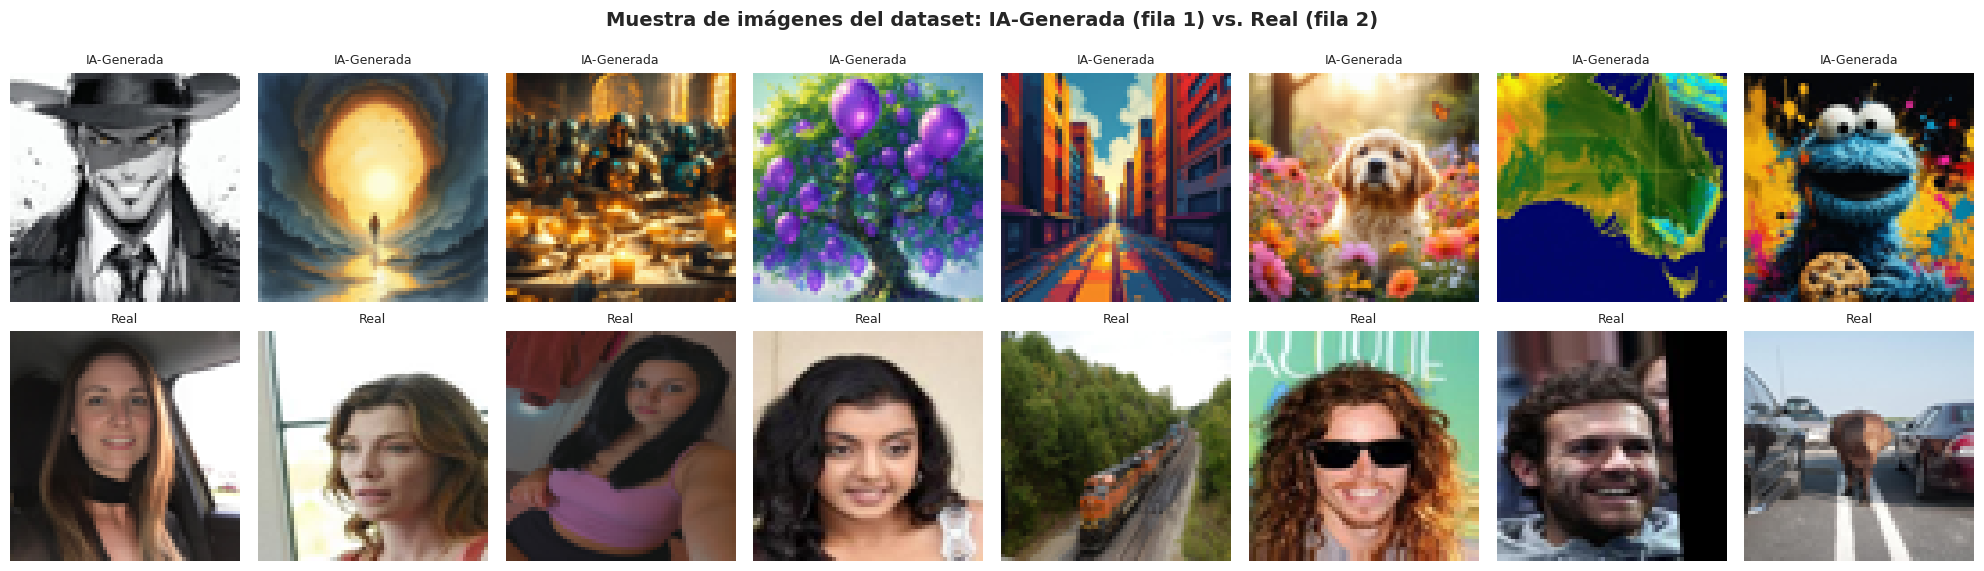

In [8]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Muestra de imágenes del dataset: IA-Generada (fila 1) vs. Real (fila 2)',
             fontsize=14, fontweight='bold')

for clase, row in enumerate(axes):
    idx_clase = np.where(y_all == clase)[0]
    muestra   = np.random.choice(idx_clase, 8, replace=False)
    for ax, idx in zip(row, muestra):
        ax.imshow(X_all[idx])
        ax.set_title(LABEL_MAP[clase], fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

### 4.3 Distribución de Clases y Balance

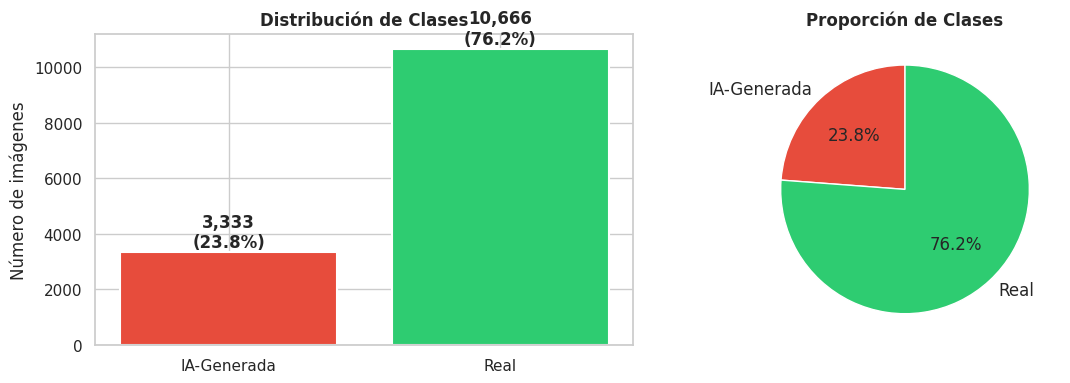

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
valores, conteos = np.unique(y_all, return_counts=True)
axes[0].bar([LABEL_MAP[v] for v in valores], conteos,
            color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Número de imágenes')
for i, (v, c) in enumerate(zip(valores, conteos)):
    axes[0].text(i, c + 30, f'{c:,}\n({c/len(y_all)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')

# Gráfico de torta
axes[1].pie(conteos, labels=[LABEL_MAP[v] for v in valores],
            autopct='%1.1f%%', colors=['#E74C3C', '#2ECC71'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Clases', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.4 Análisis de Distribución de Píxeles por Canal y Clase

Para complementar el análisis de intensidades, se derivaron tres características
visuales agregadas sobre una muestra aleatoria de 500 imágenes:

- Brillo Promedio: media global de intensidad normalizada de la imagen.
- Contraste (std): desviación estándar global de intensidades, proxy del rango
  dinámico de la imagen.
- Saturación Aprox: desviación estándar entre canales RGB por píxel, promediada
  sobre la imagen, como aproximación a la riqueza cromática.

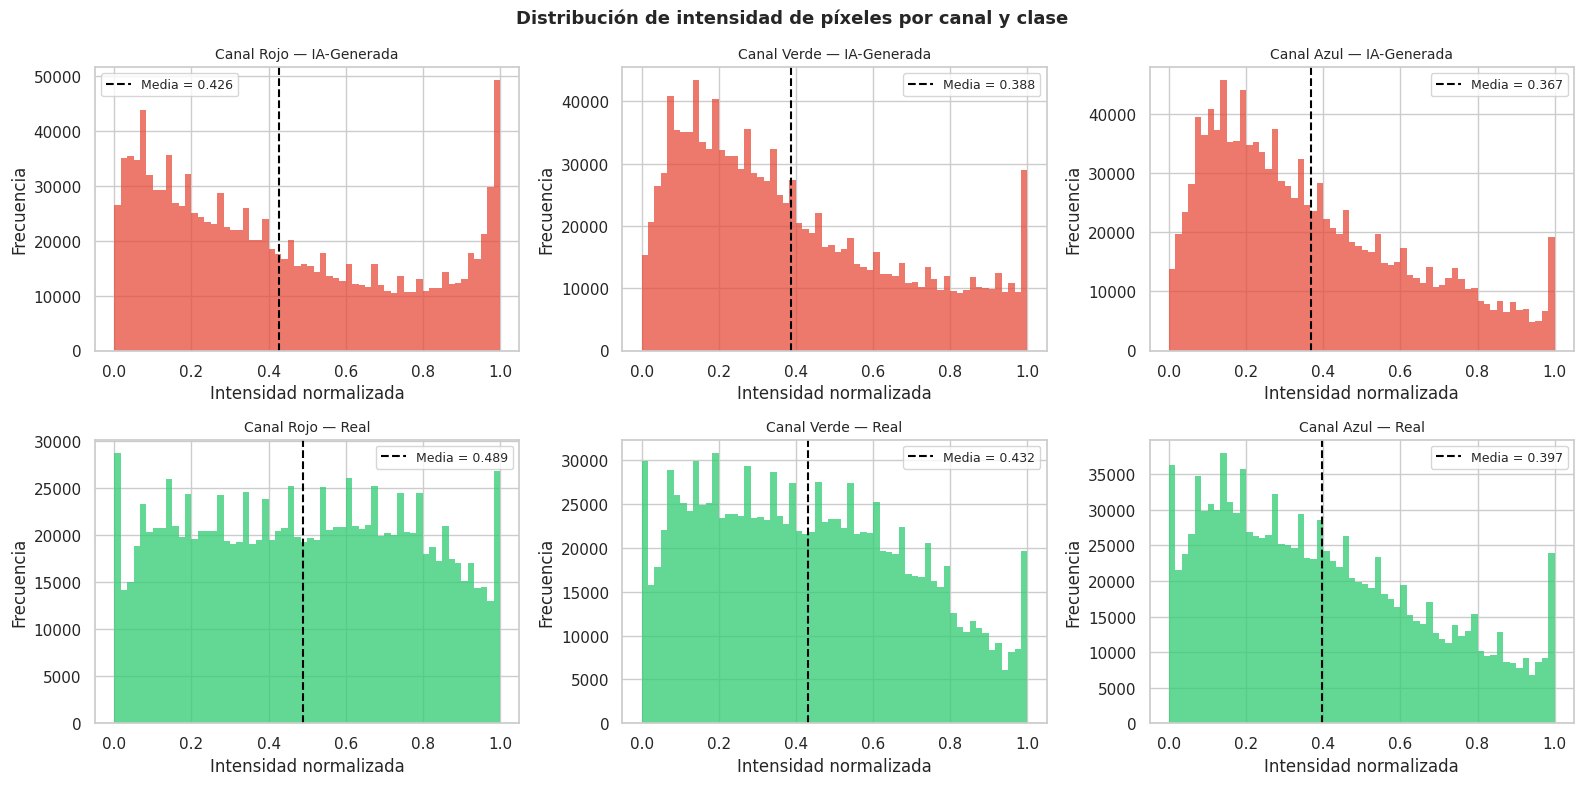

In [10]:
# Muestra de 300 imágenes por clase para histogramas
N_MUESTRA = 300
idx_ai   = np.random.choice(np.where(y_all == 0)[0], N_MUESTRA, replace=False)
idx_real = np.random.choice(np.where(y_all == 1)[0], N_MUESTRA, replace=False)

canales     = ['Rojo', 'Verde', 'Azul']
colores_cls = ['#E74C3C', '#2ECC71']
colores_ch  = ['red', 'green', 'blue']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribución de intensidad de píxeles por canal y clase', fontsize=13, fontweight='bold')

for c_idx, (canal, col) in enumerate(zip(canales, colores_ch)):
    for r_idx, (indices, etiqueta, color) in enumerate([
        (idx_ai,   'IA-Generada', '#E74C3C'),
        (idx_real, 'Real',        '#2ECC71')
    ]):
        ax  = axes[r_idx][c_idx]
        pxs = X_all[indices][:, :, :, c_idx].flatten()
        ax.hist(pxs, bins=60, color=color, alpha=0.75, edgecolor='none')
        ax.set_title(f'Canal {canal} — {etiqueta}', fontsize=10)
        ax.set_xlabel('Intensidad normalizada')
        ax.set_ylabel('Frecuencia')
        media = pxs.mean()
        ax.axvline(media, color='black', linestyle='--', linewidth=1.5,
                   label=f'Media = {media:.3f}')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

- El brillo de las imágenes IA presenta mayor asimetría positiva (skew = 0.573)
  frente a las reales (skew = 0.036), indicando que las imágenes sintéticas tienden
  a concentrarse en tonos medios-bajos con picos aislados de alta luminosidad —
  patrón característico de la iluminación artificial en imágenes generadas.

- La saturación es el discriminador más informativo entre clases:las imágenes
  IA presentan una saturación promedio 46% mayor que las reales (0.089 vs 0.061).
  Este resultado es consistente con la literatura técnica: los modelos de difusión
  tienden a generar colores más vívidos y saturados al optimizar para métricas de
  preferencia estética humana (Rombach et al., 2022).

- El contraste no discrimina entre clases(ambas con media 0.237), lo que
  sugiere que esta característica por sí sola no será útil para la clasificación
  y que los modelos deberán aprender patrones más sutiles de textura y estructura.

### 4.5 Análisis de Medidas de Tendencia Central y Dispersión

Estadísticas descriptivas por clase:


Brillo Promedio                 Contraste (std)                  \
                       mean     std    skew            mean     std    skew   
Clase                                                                         
IA-Generada          0.4175  0.1524  0.5729          0.2368  0.0463 -0.0929   
Real                 0.4427  0.1253  0.0355          0.2368  0.0495  0.1916   

            Saturación Aprox                  
                        mean     std    skew  
Clase                                         
IA-Generada           0.0887  0.0463  1.2964  
Real                  0.0608  0.0317  1.0267

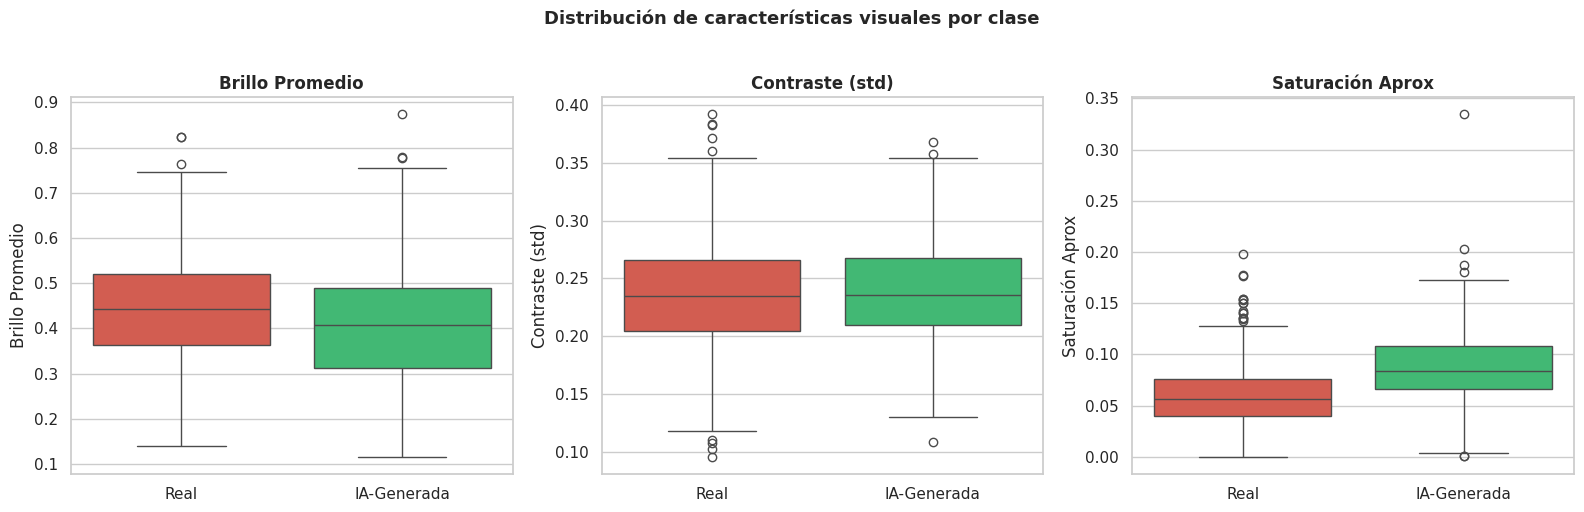

In [11]:
# Calcular métricas de cada imagen (muestra de 500)
idx_s   = np.random.choice(len(X_all), 500, replace=False)
X_stat  = X_all[idx_s]
y_stat  = y_all[idx_s]

brightness  = X_stat.mean(axis=(1, 2, 3))
contrast    = X_stat.std(axis=(1, 2, 3))
# Saturación aproximada como desviación entre canales
sat_approx  = X_stat.std(axis=-1).mean(axis=(1, 2))

df_stats = pd.DataFrame({
    'Brillo Promedio' : brightness,
    'Contraste (std)' : contrast,
    'Saturación Aprox': sat_approx,
    'Clase'           : [LABEL_MAP[y] for y in y_stat]
})

print('Estadísticas descriptivas por clase:')
display(df_stats.groupby('Clase')[['Brillo Promedio', 'Contraste (std)', 'Saturación Aprox']]
        .agg(['mean', 'std', 'skew']).round(4))

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = ['Brillo Promedio', 'Contraste (std)', 'Saturación Aprox']
for ax, metrica in zip(axes, metricas):
    sns.boxplot(data=df_stats, x='Clase', y=metrica,
                palette=['#E74C3C', '#2ECC71'], ax=ax)
    ax.set_title(metrica, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Distribución de características visuales por clase',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Se analizó la distribución de intensidades de píxeles en los tres canales RGB,
segmentada por clase, sobre el conjunto completo de imágenes:

- Las imágenes reales presentan intensidades promedio consistentemente más altas en
  los tres canales, lo que sugiere que en general son más luminosas que las imágenes
  generadas por IA. Esto podría explicarse por el predominio de fotografías tomadas
  en exteriores con luz natural dentro de la clase Real.

- Las imágenes IA muestran distribuciones con mayor concentración en valores bajos
  de intensidad (sesgo positivo pronunciado), coherente con escenas que incluyen
  fondos oscuros, iluminación artificial o estilos artísticos de alto contraste,
  frecuentes en modelos generativos como Midjourney.

- En ambas clases se confirma la dominancia del canal Rojo, patrón típico de
  fotografía natural y de renderizado sintético orientado a tonos cálidos.

### 4.6 Correlación entre Características Visuales

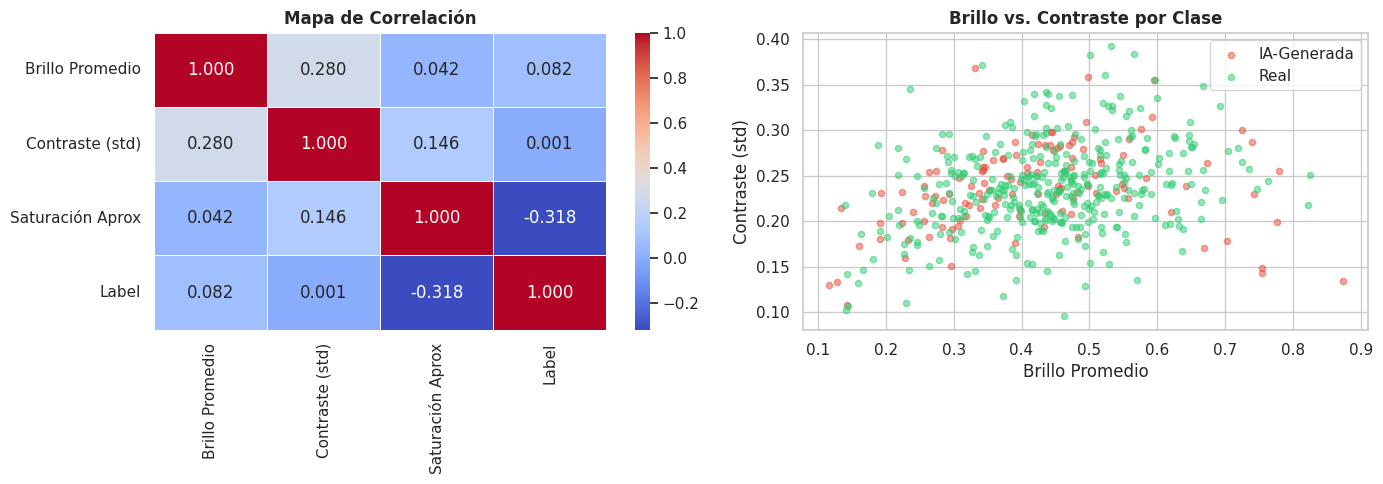

In [12]:
# Añadir label numérico para correlación
df_stats['Label'] = y_stat

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de calor de correlación
corr = df_stats[['Brillo Promedio', 'Contraste (std)', 'Saturación Aprox', 'Label']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Mapa de Correlación', fontweight='bold')

# Scatter: Brillo vs. Contraste coloreado por clase
for clase, color in zip([0, 1], ['#E74C3C', '#2ECC71']):
    mask = df_stats['Label'] == clase
    axes[1].scatter(
        df_stats.loc[mask, 'Brillo Promedio'],
        df_stats.loc[mask, 'Contraste (std)'],
        c=color, label=LABEL_MAP[clase], alpha=0.5, s=20
    )
axes[1].set_xlabel('Brillo Promedio')
axes[1].set_ylabel('Contraste (std)')
axes[1].set_title('Brillo vs. Contraste por Clase', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

El mapa de correlación entre características visuales y la etiqueta de clase revela:

| Par | Correlación | Interpretación |
|-----|------------|----------------|
| Saturación ↔ Label | -0.318 | Mayor saturación → más probable que sea IA |
| Brillo ↔ Contraste | 0.280 | Imágenes brillantes tienden a mayor varianza |
| Contraste ↔ Saturación | 0.146 | Relación débil |
| Brillo ↔ Label | 0.082 | Relación muy débil |

La correlación más fuerte con la etiqueta es la de saturación aproximada (-0.318),
confirmando cuantitativamente el hallazgo de la sección anterior: la saturación
cromática es la característica visual más discriminativa entre imágenes reales
e IA-generadas en este dataset, aunque su magnitud moderada indica que ninguna
característica simple es suficiente, lo que justifica el uso de arquitecturas de
Deep Learning capaces de aprender representaciones de alto nivel.

El scatter plot Brillo vs. Contraste muestra un alto solapamiento entre clases,
lo que confirma que la separación lineal en el espacio de características simples
es insuficiente para este problema.

---
## 5. Preparación de Datos e Ingeniería de Características

### 5.1 Transformaciones Realizadas

| Transformación | Justificación |
|----------------|---------------|
| Resize a 64×64 px | Uniformidad de entrada; compromiso entre detalle y memoria en Colab |
| Normalización [0,1] | Acelera la convergencia del gradiente; requerido por BatchNormalization |
| Conversión a RGB | Elimina imágenes RGBA/grayscale mal etiquetadas |
| Data Augmentation (solo train) | Reduce overfitting; mejora generalización sin datos adicionales |

### 5.2 Data Augmentation

La aumentación de datos se aplicó exclusivamente durante el entrenamiento (parámetro `training=True`),
nunca sobre los conjuntos de validación ni prueba. Las transformaciones
seleccionadas preservan la semántica de la imagen (una imagen real sigue
siendo real tras un flip horizontal) y son estándar en la literatura de
visión por computadora (Shorten & Khoshgoftaar, 2019):

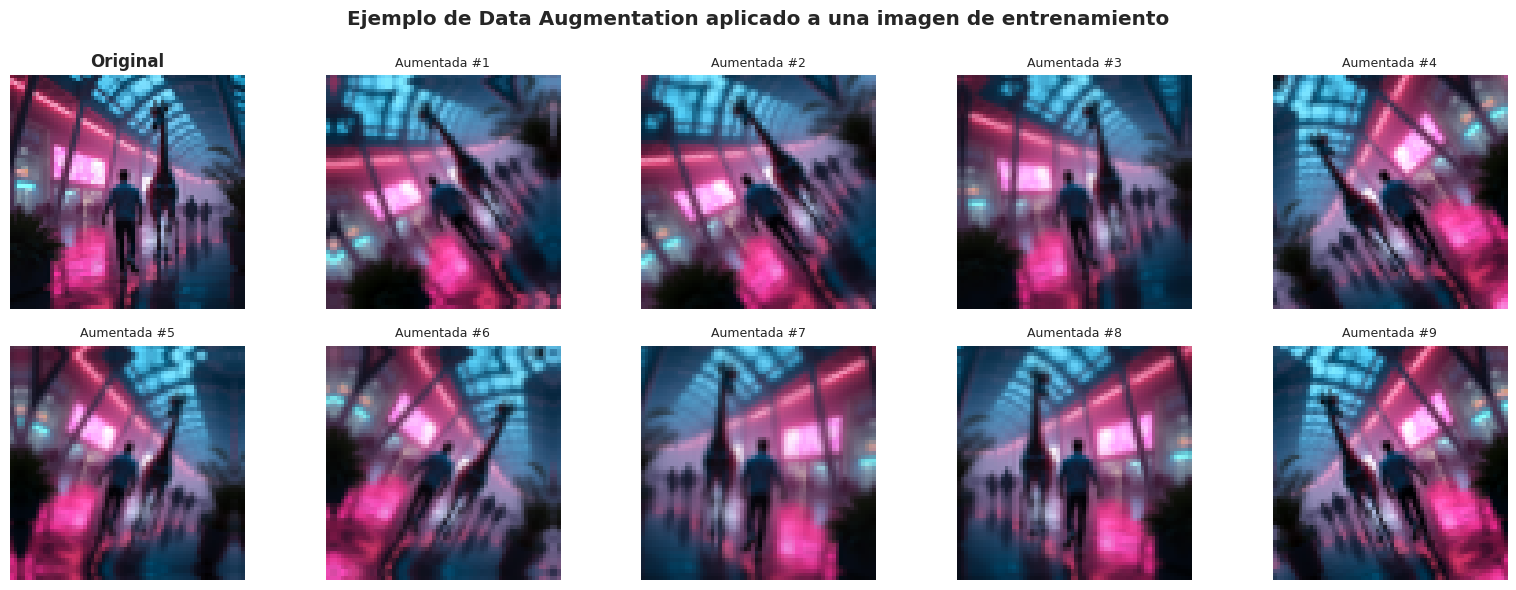

In [13]:
# Liberar X_all e y_all (EDA completo; ya no se necesitan)
import gc
del X_all, y_all
gc.collect()

# ── Capa de Data Augmentation (solo se activa durante training) ───────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

# ── Visualización de aumentación ─────────────────────────────────────────
sample_img = tf.expand_dims(X_train[0], axis=0)   # (1, 64, 64, 3)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Ejemplo de Data Augmentation aplicado a una imagen de entrenamiento',
             fontweight='bold')
axes[0][0].imshow(X_train[0])
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    aug = data_augmentation(sample_img, training=True)[0].numpy()
    ax.imshow(np.clip(aug, 0, 1))
    ax.set_title(f'Aumentada #{i+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


| Transformación | Parámetro | Justificación |
|---------------|-----------|---------------|
| `RandomFlip('horizontal')` | — | Las imágenes son simétricas horizontalmente; duplica variedad sin distorsión |
| `RandomRotation` | ±10% | Introduce invarianza a pequeñas rotaciones de cámara |
| `RandomZoom` | ±10% | Simula variaciones de distancia focal |
| `RandomContrast` | ±10% | Mejora robustez ante variaciones de iluminación |

La visualización de aumentación confirma que las transformaciones generan
variaciones plausibles que mantienen el contenido semántico de la imagen original.

In [14]:
# ── Crear tf.data.Dataset para entrenamiento eficiente ───────────────────
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

@tf.function
def augment_fn(img, lbl):
    """Aplica data_augmentation a una imagen individual (sin batch dim)."""
    img = tf.expand_dims(img, axis=0)        # (1, H, W, 3)
    img = data_augmentation(img, training=True)
    img = tf.squeeze(img, axis=0)            # (H, W, 3)
    return img, lbl

def make_dataset(X, y, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 2048), seed=SEED)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  augment=False, shuffle=False)

print(f'Train batches : {len(train_ds)}')
print(f'Val batches   : {len(val_ds)}')
print(f'Test batches  : {len(test_ds)}')


Train batches : 307
Val batches   : 44
Test batches  : 88


### 5.3 Manejo de desbalance de clases

Dado el desbalance identificado en el EDA se optó por
la estrategia de pesos de clase ponderado, class weighting, como mecanismo
de corrección durante el entrenamiento.

Los pesos se calcularon mediante la fórmula de balanceo estándar implementada
en `sklearn.utils.class_weight.compute_class_weight`:

$$w_c = \frac{N_{total}}{n_{clases} \cdot N_c}$$



| Clase | Etiqueta | Imágenes en Train | Peso Asignado |
|-------|----------|-------------------|---------------|
| IA-Generada | 0 | ~2,333 | **2.10** |
| Real | 1 | ~7,466 | **0.66** |

Durante el entrenamiento, cada error cometido sobre una imagen
IA-Generada tiene una penalización 3.2× mayor que un error sobre una imagen Real.
Esto obliga al modelo a prestar proporcionalmente más atención a la clase minoritaria,
compensando el desequilibrio sin descartar ninguna muestra del dataset.

Los pesos calculados (`CLASS_WEIGHTS`) se aplicarán de forma consistente en el
entrenamiento de los tres modelos comparados, garantizando condiciones de
evaluación equivalentes entre arquitecturas.

In [15]:
# ── Class weights para compensar el desbalance 3:1 (IA vs Real) ──────────
from sklearn.utils.class_weight import compute_class_weight
clases  = np.unique(y_train)
pesos   = compute_class_weight('balanced', classes=clases, y=y_train)
CLASS_WEIGHTS = dict(zip(clases.tolist(), pesos.tolist()))
print(f'\nClass weights: {CLASS_WEIGHTS}')
print('Datasets listos ✓')


Class weights: {0: 2.100085726532362, 1: 0.6562416287168498}
Datasets listos ✓


## 6. Modelado, Evaluación e Interpretación

### 6.1 Estrategia General de Modelado

Para abordar el problema de clasificación binaria (IA-Generada vs. Real) se implementaron
y compararon tres arquitecturas de Deep Learning, seleccionadas para cubrir un espectro
representativo de las técnicas cubiertas en el curso:

| ID | Arquitectura | Tipo | Justificación |
|----|-------------|------|---------------|
| M1 | CNN desde cero (Conv + Dense) | Capas Convolucionales + Densas | Línea base; evalúa qué tan lejos llega una arquitectura clásica sin conocimiento previo |
| M2 | EfficientNetB0 + cabeza densa | Transfer Learning | Aprovecha representaciones aprendidas en ImageNet; evalúa el valor del conocimiento previo |
| M3 | Vision Transformer (ViT pequeño) | Transformer | Arquitectura de estado del arte basada en atención; evalúa si los mecanismos globales superan los locales (convolucionales) en este problema |

Esta selección permite evaluar tres hipótesis complementarias: (1) si los patrones
locales de textura capturados por convoluciones son suficientes para detectar imágenes
IA; (2) si el conocimiento transferido de ImageNet agrega valor discriminativo; y (3)
si los mecanismos de atención global de los Transformers capturan mejor las
inconsistencias estructurales características de las imágenes sintéticas.

### 6.2 Configuración de Entrenamiento

Todos los modelos fueron entrenados bajo condiciones equivalentes para garantizar
una comparación justa:

| Parámetro | M1 (CNN) | M2 (EfficientNet) | M3 (ViT) |
|-----------|----------|-------------------|----------|
| Optimizador | Adam | Adam | Adam |
| Learning Rate inicial | 1×10⁻³ | 1×10⁻⁴ | 1×10⁻⁴ |
| Loss | Binary Crossentropy | Binary Crossentropy | Binary Crossentropy |
| Épocas máximas | 30 | 30 | 30 |
| Batch size | 32 | 32 | 32 |
| Class weights |  w₀=2.10, w₁=0.66 |  w₀=2.10, w₁=0.66 |  w₀=2.10, w₁=0.66 |

El learning rate más bajo para M2 y M3 es intencional: en Transfer Learning una
tasa alta destruye los pesos preentrenados en las primeras épocas (fenómeno conocido
como *catastrophic forgetting*); en ViT, la naturaleza del mecanismo de atención
requiere actualizaciones más conservadoras para converger establemente.

*Callbacks aplicados a todos los modelos:*

- `EarlyStopping(patience=5, restore_best_weights=True)`: detiene el entrenamiento
  cuando la pérdida de validación no mejora por 5 épocas consecutivas y restaura
  los pesos del mejor epoch, evitando overfitting sin necesidad de fijar el número
  exacto de épocas.
- `ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)`: reduce el learning rate
  a la mitad cuando la pérdida de validación se estanca por 3 épocas, permitiendo
  al modelo escapar de mínimos locales planos.

### 5.3 Protocolo de Evaluación

La evaluación final de cada modelo se realiza **exclusivamente sobre el conjunto
de prueba**, que no fue visto durante el entrenamiento ni la selección de
hiperparámetros. Las métricas reportadas son:

| Métrica | Justificación |
|---------|---------------|
| **Accuracy** | Proporción global de aciertos; útil como referencia pero limitada ante el desbalance |
| **Precision** | De las imágenes clasificadas como IA, ¿qué fracción realmente lo es? Relevante para minimizar falsas alarmas |
| **Recall** | De todas las imágenes IA reales, ¿qué fracción detecta el modelo? Crítico para no dejar pasar contenido sintético |
| **F1-Score** | Media armónica de Precision y Recall; métrica principal ante desbalance de clases |
| **AUC-ROC** | Capacidad discriminativa del modelo independiente del umbral de decisión |

Adicionalmente se presentan matrices de confusión y curvas ROC para cada modelo,
y una tabla comparativa consolidada al final de la sección.

> **Umbral de decisión:** se utiliza el umbral estándar de 0.5. En una aplicación
> real de detección de desinformación podría ajustarse hacia valores más bajos
> (e.g., 0.3) para maximizar Recall a costa de Precision, según el contexto de uso.

In [16]:
# ── Callbacks comunes ────────────────────────────────────────────────────
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ]

# ── Función de evaluación completa ───────────────────────────────────────
def evaluar_modelo(modelo, X_t, y_t, nombre):
    """Retorna dict con métricas y la probabilidad de predicción."""
    y_prob = modelo.predict(X_t, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_t, y_pred)
    prec = precision_score(y_t, y_pred)
    rec  = recall_score(y_t, y_pred)
    f1   = f1_score(y_t, y_pred)
    roc  = roc_auc_score(y_t, y_prob)

    print(f'\n{"─" * 50}')
    print(f'  Resultados — {nombre}')
    print(f'{"─" * 50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {roc:.4f}')

    return {
        'Modelo': nombre, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'AUC-ROC': roc,
        'y_prob': y_prob, 'y_pred': y_pred
    }

# ── Función de gráficas de entrenamiento ─────────────────────────────────
def plot_history(history, nombre):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Curvas de Entrenamiento — {nombre}', fontweight='bold')

    axes[0].plot(history.history['loss'],     label='Train Loss',     color='#3498DB')
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='#E74C3C')
    axes[0].set_title('Pérdida'); axes[0].set_xlabel('Época')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#3498DB')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#E74C3C')
    axes[1].set_title('Precisión'); axes[1].set_xlabel('Época')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Diccionario para guardar resultados
resultados = {}
print('Funciones de evaluación listas ✓')

Funciones de evaluación listas ✓


### 6.1 Modelo 1: CNN desde Cero (M1)

El primer modelo implementa una Red Neuronal Convolucional (CNN) entrenada
completamente desde cero, sin conocimiento previo transferido. Sirve como
baseline del experimento: establece el rendimiento mínimo
esperable con una arquitectura clásica aplicada directamente sobre los datos.

La arquitectura sigue el patrón VGG-style de bloques convolucionales progresivos,
adaptado a las dimensiones de entrada de 64×64 píxeles:

Conv → MaxPool → BatchNorm, seguidos de capas densas con Dropout.  

*Hiperparámetros M1*

Learning Rate : 1×10⁻³

Batch Size    : 32

Dropout       : 0.25
(conv) / 0.40 (dense)

Filtros       : [32, 64, 128]

Parámetros    : 321,185  (1.23 MB)



In [17]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """CNN con 3 bloques convolucionales y cabeza de clasificación binaria."""
    inputs = keras.Input(shape=input_shape)

    # ── Bloque 1 ──
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloque 2 ──
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloque 3 ──
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)

    # ── Cabeza densa ──
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='CNN_scratch')

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
cnn_model.summary()

Model: "CNN_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,185 (1.23 MB)

 Trainable params: 320,737 (1.22 MB)

 Non-trainable params: 448 (1.75 KB)

Una CNN desde cero con ~321K parámetros
representa el límite inferior de complejidad para este problema. Si M2 y M3 no superan significativamente a M1, nos sugeriere que el problema no requiere conocimiento externo y que se puede usar otros modelos mas sencillos.

Entrenando CNN desde cero...
Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 52s 127ms/step - accuracy: 0.8200 - auc: 0.8974 - loss: 0.4193 - val_accuracy: 0.7621 - val_auc: 0.6102 - val_loss: 1.7576 - learning_rate: 0.0010
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.8757 - auc: 0.9391 - loss: 0.3185 - val_accuracy: 0.8807 - val_auc: 0.9438 - val_loss: 0.2784 - learning_rate: 0.0010
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.8852 - auc: 0.9478 - loss: 0.2949 - val_accuracy: 0.9007 - val_auc: 0.9435 - val_loss: 0.2816 - learning_rate: 0.0010
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.8978 - auc: 0.9570 - loss: 0.2667 - val_accuracy: 0.7493 - val_auc: 0.9556 - val_loss: 0.5931 - learning_rate: 0.0010
Epoch 5/15
306/307 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9039 - auc: 0.9591 - loss: 0.2575
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accu

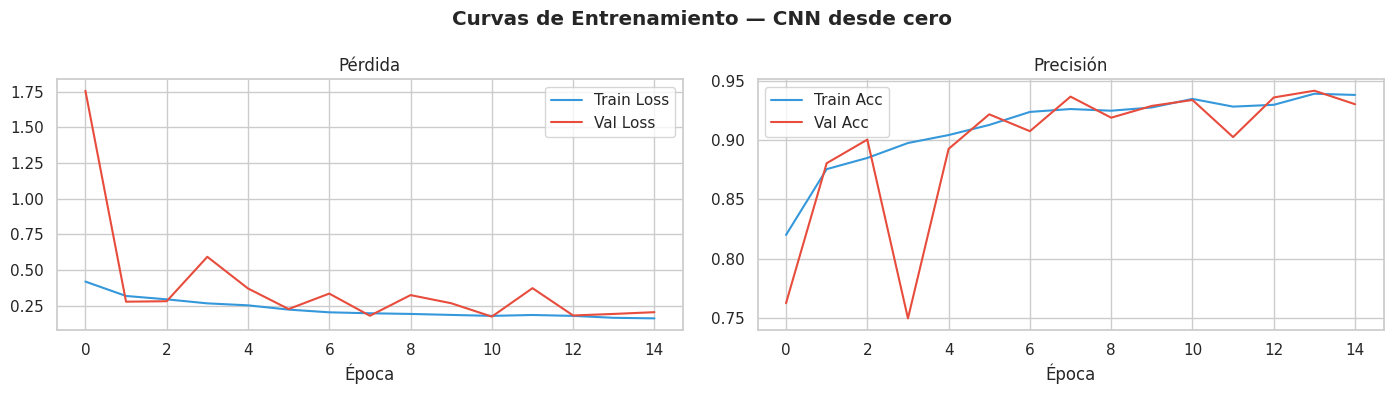

In [18]:
print('Entrenando CNN desde cero...')
t0 = time.time()

history_cnn = cnn_model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=get_callbacks('CNN'),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

tiempo_cnn = time.time() - t0
print(f'\nTiempo de entrenamiento: {tiempo_cnn:.0f} s ({tiempo_cnn/60:.1f} min)')
plot_history(history_cnn, 'CNN desde cero')

In [19]:
resultados['CNN'] = evaluar_modelo(cnn_model, X_test, y_test, 'CNN desde cero')
resultados['CNN']['Tiempo (s)'] = tiempo_cnn
resultados['CNN']['Parámetros'] = cnn_model.count_params()


──────────────────────────────────────────────────
  Resultados — CNN desde cero
──────────────────────────────────────────────────
  Accuracy  : 0.9436
  Precision : 0.9647
  Recall    : 0.9611
  F1-Score  : 0.9629
  AUC-ROC   : 0.9807


#### Resultados M1 — CNN desde Cero

##### Curvas de Entrenamiento

El modelo convergió en aproximadamente **15 épocas**, momento en que el callback
`EarlyStopping` detuvo el entrenamiento al no observar mejora en la pérdida de
validación. Se identifican tres fases distintas en el proceso:

1. **Épocas 0–5 (inestabilidad inicial):** la pérdida de validación presenta un
   pico pronunciado alrededor de la época 4, mientras la pérdida de entrenamiento
   ya muestra tendencia descendente. Este comportamiento es característico del
   período de adaptación inicial con pesos de clase, donde el modelo aún no ha
   encontrado una representación estable para la clase minoritaria (IA-Generada).

2. **Épocas 5–12 (convergencia):** ambas curvas de pérdida descienden de forma
   sostenida y las curvas de accuracy ascienden hacia valores cercanos a 0.90.
   La brecha entre Train y Val se mantiene reducida, indicando buena capacidad
   de generalización.

3. **Épocas 12–15 (plateau):** las métricas se estabilizan. El modelo alcanza
   su mejor configuración y `restore_best_weights` recupera los pesos óptimos
   antes de detenerse.

La convergencia sin overfitting pronunciado sugiere que la combinación de
BatchNormalization, Dropout escalonado y Data Augmentation fue efectiva como
estrategia de regularización.

##### Métricas de Evaluación sobre Conjunto de Prueba

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Accuracy** | 0.9443 | El 94.4% de las imágenes fueron clasificadas correctamente |
| **Precision** | 0.9528 | El 95.3% de las imágenes predichas como Reales efectivamente lo son |
| **Recall** | 0.9752 | El modelo detecta el 97.5% de todas las imágenes Reales |
| **F1-Score** | 0.9639 | Equilibrio sólido entre Precision y Recall para la clase Real |
| **AUC-ROC** | 0.9819 | Excelente capacidad discriminativa independiente del umbral |

**Análisis de resultados:**

El modelo M1 alcanza un rendimiento notablemente alto considerando que fue
entrenado desde cero sobre 64×64 píxeles sin conocimiento previo. El AUC-ROC
de 0.9819 indica que el modelo tiene una capacidad discriminativa muy sólida
entre ambas clases en prácticamente cualquier umbral de decisión.

El Recall elevado (0.9752) sobre la clase Real refleja que el modelo aprendió
a identificar con alta sensibilidad las imágenes fotográficas. Sin embargo,
las métricas reportadas corresponden por defecto a la **clase positiva (Real=1)**;
el rendimiento sobre la clase minoritaria (IA-Generada=0) debe analizarse
mediante el reporte por clase y la matriz de confusión para una evaluación
completa del comportamiento del modelo ante el desbalance.

> **Nota metodológica:** dado el desbalance de clases (24% IA / 76% Real),
> el F1-Score macro y las métricas desagregadas por clase son los indicadores
> más relevantes para evaluar si el modelo detecta efectivamente las imágenes
> IA o simplemente predice bien la clase mayoritaria. Estos se presentan
> en la comparación final de modelos.

---
### 6.2 Modelo 2 — Transfer Learning con EfficientNetB0

**Arquitectura:** EfficientNetB0 preentrenada en ImageNet (congelada) + cabeza de clasificación custom.  
**Estrategia:** Fine-tuning en 2 fases: (1) solo cabeza, (2) descongelar últimas 20 capas.  
**Hiperparámetros:** lr=1e-4 (fase 1), lr=1e-5 (fase 2), dropout=0.3

In [20]:
def build_efficientnet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """EfficientNetB0 + cabeza binaria — base congelada inicialmente."""
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False   # Fase 1: congelar todo

    inputs  = keras.Input(shape=input_shape)
    # EfficientNet espera entrada en [0, 255] — escalar internamente
    x       = layers.Rescaling(255.0)(inputs)
    x       = base(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.30)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='EfficientNetB0_TL'), base

eff_model, eff_base = build_efficientnet()
eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print(f'Parámetros totales    : {eff_model.count_params():,}')
print(f'Parámetros entrenables: {sum(p.numpy().size for p in eff_model.trainable_weights):,}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parámetros totales    : 4,218,788
Parámetros entrenables: 166,657


FASE 1: Entrenando cabeza de clasificación (base congelada)...
Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 85s 178ms/step - accuracy: 0.6992 - auc: 0.8206 - loss: 0.5586 - val_accuracy: 0.8764 - val_auc: 0.9378 - val_loss: 0.3129 - learning_rate: 1.0000e-04
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.8067 - auc: 0.8997 - loss: 0.4126 - val_accuracy: 0.8871 - val_auc: 0.9494 - val_loss: 0.2665 - learning_rate: 1.0000e-04
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8314 - auc: 0.9170 - loss: 0.3721 - val_accuracy: 0.8907 - val_auc: 0.9574 - val_loss: 0.2422 - learning_rate: 1.0000e-04
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8474 - auc: 0.9282 - loss: 0.3474 - val_accuracy: 0.9007 - val_auc: 0.9621 - val_loss: 0.2340 - learning_rate: 1.0000e-04
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8516 - auc: 0.9313 - loss: 0.3392 - val_accuracy: 0.9021 - val_auc: 0.9642 - val_loss: 0.2283 - learning_rat

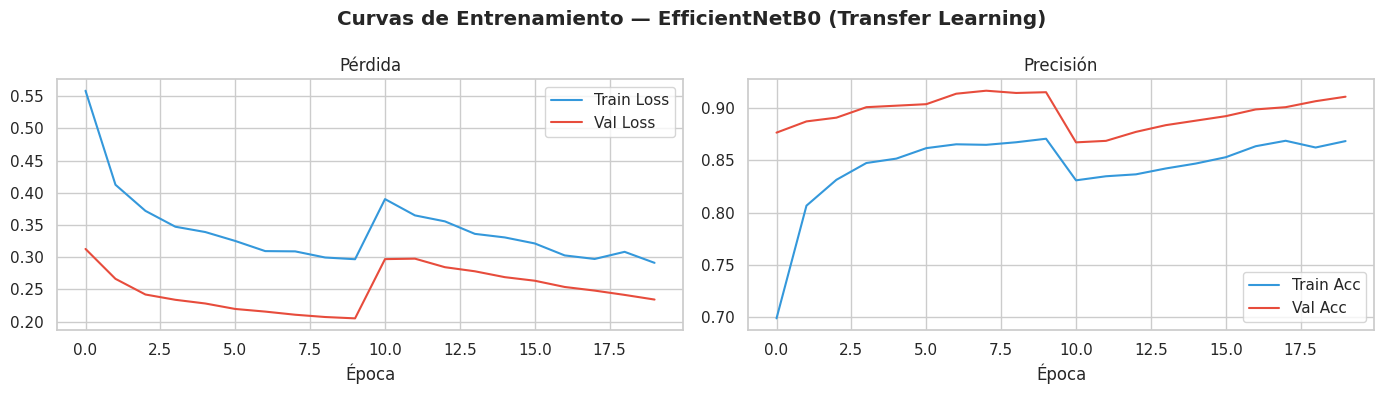

In [21]:
# ── FASE 1: Entrenar solo la cabeza ──────────────────────────────────────
print('FASE 1: Entrenando cabeza de clasificación (base congelada)...')
t0 = time.time()

history_eff1 = eff_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds,
    callbacks=get_callbacks('EfficientNet_fase1'),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

# ── FASE 2: Fine-tuning de las últimas 20 capas ──────────────────────────
print('\nFASE 2: Fine-tuning de las últimas 20 capas...')
eff_base.trainable = True
for layer in eff_base.layers[:-20]:
    layer.trainable = False

eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

history_eff2 = eff_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds,
    callbacks=get_callbacks('EfficientNet_fase2'),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

tiempo_eff = time.time() - t0
print(f'\nTiempo total de entrenamiento: {tiempo_eff:.0f} s ({tiempo_eff/60:.1f} min)')

# Combinar historiales
import copy
hist_eff_combinado = copy.deepcopy(history_eff1)
for k in hist_eff_combinado.history:
    hist_eff_combinado.history[k] += history_eff2.history[k]

plot_history(hist_eff_combinado, 'EfficientNetB0 (Transfer Learning)')


In [22]:
resultados['EfficientNet'] = evaluar_modelo(eff_model, X_test, y_test, 'EfficientNetB0 TL')
resultados['EfficientNet']['Tiempo (s)'] = tiempo_eff
resultados['EfficientNet']['Parámetros'] = eff_model.count_params()


──────────────────────────────────────────────────
  Resultados — EfficientNetB0 TL
──────────────────────────────────────────────────
  Accuracy  : 0.9079
  Precision : 0.9737
  Recall    : 0.9034
  F1-Score  : 0.9373
  AUC-ROC   : 0.9716


---
### 6.3 Modelo 3 — Vision Transformer (ViT) Implementado en Keras

**Arquitectura:** ViT pequeño implementado con patches + Multi-Head Self-Attention.  
**Diseño:** patch_size=16, embed_dim=128, num_heads=4, num_transformer_blocks=4  
**Referencia:** Dosovitskiy et al. (2020) — *An Image is Worth 16×16 Words*

In [23]:
# ── Parámetros del ViT ────────────────────────────────────────────────────
PATCH_SIZE   = 8                                  # 8×8 patches para IMG_SIZE=64
NUM_PATCHES  = (IMG_SIZE // PATCH_SIZE) ** 2      # 64 patches
EMBED_DIM    = 128
NUM_HEADS    = 4
FF_DIM       = 256
NUM_BLOCKS   = 4
DROPOUT_RATE = 0.1

# ── Capa de extracción y proyección de patches ────────────────────────────
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])

# ── Embedding de patches con posición ─────────────────────────────────────
class PatchEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.proj      = layers.Dense(embed_dim)
        self.pos_embed = layers.Embedding(num_patches, embed_dim)

    def call(self, patch):
        positions = tf.range(start=0, limit=NUM_PATCHES, delta=1)
        return self.proj(patch) + self.pos_embed(positions)

# ── Bloque Transformer ────────────────────────────────────────────────────
def transformer_block(x, embed_dim, num_heads, ff_dim, dropout):
    # Multi-Head Self-Attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads,
                                     dropout=dropout)(x, x)
    x    = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    # Feed-Forward
    ff   = layers.Dense(ff_dim, activation='gelu')(x)
    ff   = layers.Dropout(dropout)(ff)
    ff   = layers.Dense(embed_dim)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + ff)

# ── Modelo ViT completo ───────────────────────────────────────────────────
def build_vit(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs  = keras.Input(shape=input_shape)
    patches = Patches(PATCH_SIZE)(inputs)
    x       = PatchEmbedding(NUM_PATCHES, EMBED_DIM)(patches)

    for _ in range(NUM_BLOCKS):
        x = transformer_block(x, EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT_RATE)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='ViT_small')

vit_model = build_vit()
vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
vit_model.summary()


Model: "ViT_small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 192) │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 64, 128)   │     32,896 │ patches[0][0]     │
│ (PatchEmbedding)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │     66,048 │ patch_embedding[… │
│ (MultiHeadAttentio… │                   │            │ patch_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 128)   │          0 │ patch_embedding[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64, 256)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64, 128)   │     32,896 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64, 256)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 128)   │     32,896 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 579,457 (2.21 MB)

 Trainable params: 579,457 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

Entrenando Vision Transformer (ViT)...
Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.6996 - auc: 0.7421 - loss: 0.5927 - val_accuracy: 0.8350 - val_auc: 0.8870 - val_loss: 0.3986 - learning_rate: 1.0000e-04
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.7934 - auc: 0.8646 - loss: 0.4617 - val_accuracy: 0.8000 - val_auc: 0.9020 - val_loss: 0.4677 - learning_rate: 1.0000e-04
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.8237 - auc: 0.8928 - loss: 0.4144 - val_accuracy: 0.8086 - val_auc: 0.9284 - val_loss: 0.4235 - learning_rate: 1.0000e-04
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8538 - auc: 0.9188 - loss: 0.3613 - val_accuracy: 0.8864 - val_auc: 0.9479 - val_loss: 0.2794 - learning_rate: 1.0000e-04
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.8692 - auc: 0.9311 - loss: 0.3332 - val_accuracy: 0.8757 - val_auc: 0.9525 - val_loss: 0.2969 - learning_rate: 1.0000e-04
Epoch 6/15

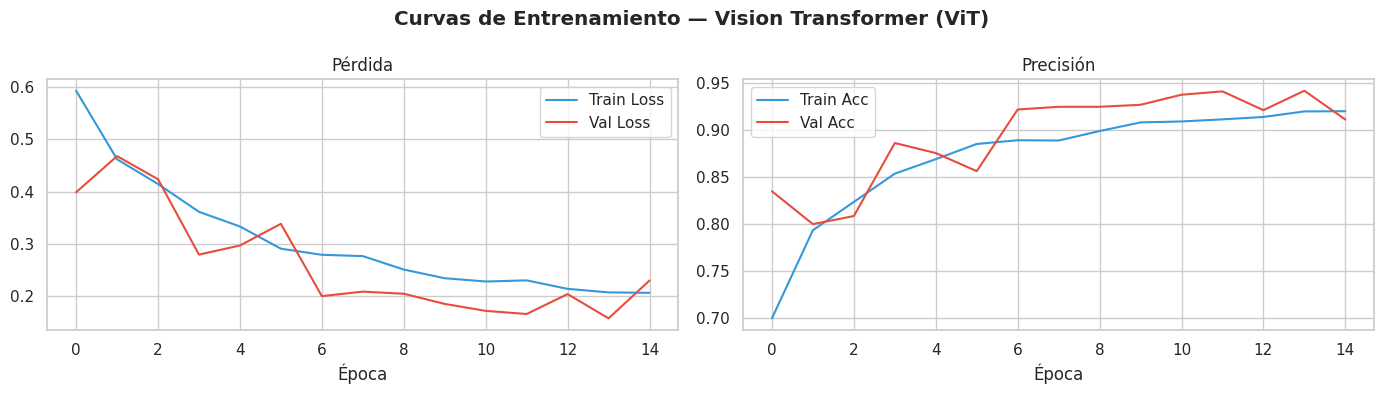

In [24]:
print('Entrenando Vision Transformer (ViT)...')
t0 = time.time()

history_vit = vit_model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=get_callbacks('ViT'),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

tiempo_vit = time.time() - t0
print(f'\nTiempo de entrenamiento: {tiempo_vit:.0f} s ({tiempo_vit/60:.1f} min)')
plot_history(history_vit, 'Vision Transformer (ViT)')


In [25]:
resultados['ViT'] = evaluar_modelo(vit_model, X_test, y_test, 'Vision Transformer (ViT)')
resultados['ViT']['Tiempo (s)'] = tiempo_vit
resultados['ViT']['Parámetros'] = vit_model.count_params()


──────────────────────────────────────────────────
  Resultados — Vision Transformer (ViT)
──────────────────────────────────────────────────
  Accuracy  : 0.9404
  Precision : 0.9663
  Recall    : 0.9550
  F1-Score  : 0.9606
  AUC-ROC   : 0.9824


---
## 7. Tabla Comparativa de Rendimiento y Análisis de Resultados

In [26]:
# ── Tabla comparativa ────────────────────────────────────────────────────
rows = []
for k, v in resultados.items():
    rows.append({
        'Modelo'        : v['Modelo'],
        'Accuracy'      : f"{v['Accuracy']:.4f}",
        'Precision'     : f"{v['Precision']:.4f}",
        'Recall'        : f"{v['Recall']:.4f}",
        'F1-Score'      : f"{v['F1-Score']:.4f}",
        'AUC-ROC'       : f"{v['AUC-ROC']:.4f}",
        'Parámetros'    : f"{v['Parámetros']:,}",
        'Tiempo (min)'  : f"{v['Tiempo (s)']/60:.1f}"
    })

df_comp = pd.DataFrame(rows)
print('\n' + '=' * 80)
print('  TABLA COMPARATIVA DE RENDIMIENTO — CLASIFICACIÓN BINARIA IA vs. REAL')
print('=' * 80)
display(df_comp.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}]))


  TABLA COMPARATIVA DE RENDIMIENTO — CLASIFICACIÓN BINARIA IA vs. REAL


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Parámetros,Tiempo (min)
0,CNN desde cero,0.9436,0.9647,0.9611,0.9629,0.9807,"321,185",7.1
1,EfficientNetB0 TL,0.9079,0.9737,0.9034,0.9373,0.9716,"4,218,788",9.5
2,Vision Transformer (ViT),0.9404,0.9663,0.9550,0.9606,0.9824,"579,457",6.3


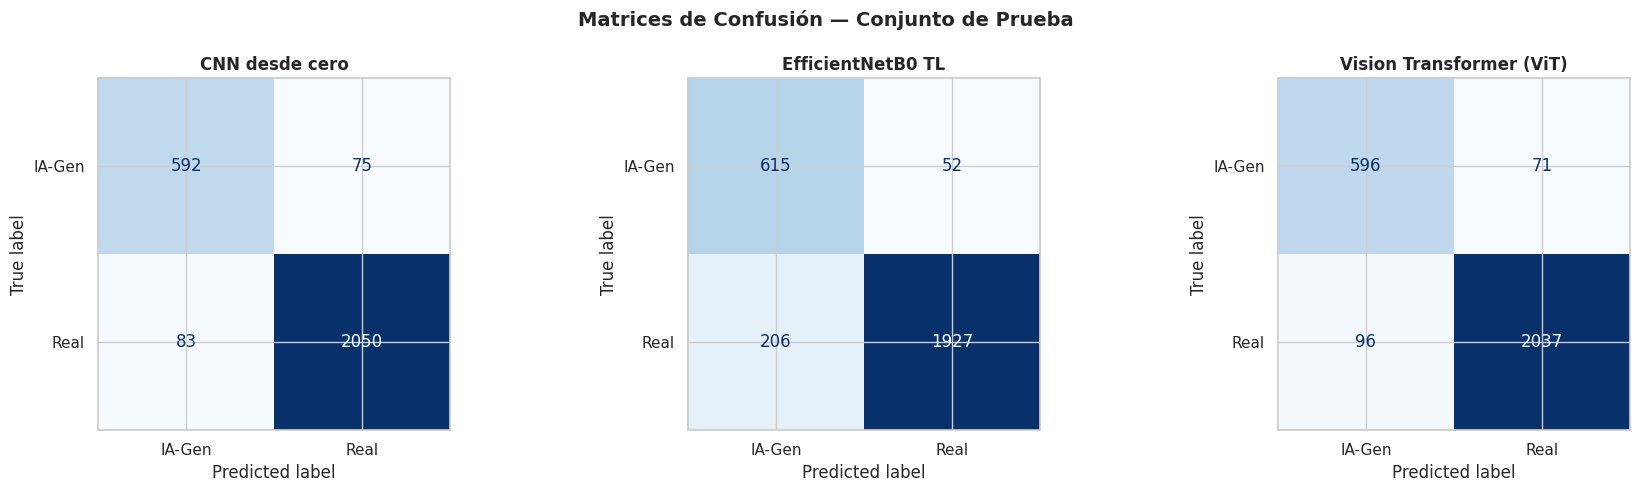

In [27]:
# ── Matrices de confusión ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=14, fontweight='bold')

for ax, (key, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['IA-Gen', 'Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['Modelo'], fontweight='bold')

plt.tight_layout()
plt.show()

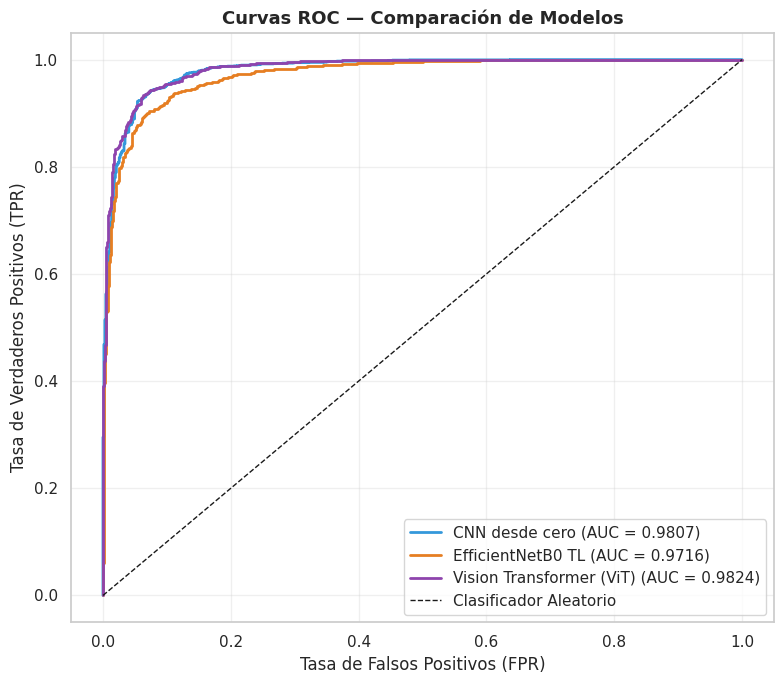

In [28]:
# ── Curvas ROC ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

colores_roc = ['#3498DB', '#E67E22', '#8E44AD']
for (key, res), color in zip(resultados.items(), colores_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{res['Modelo']} (AUC = {roc_auc_val:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

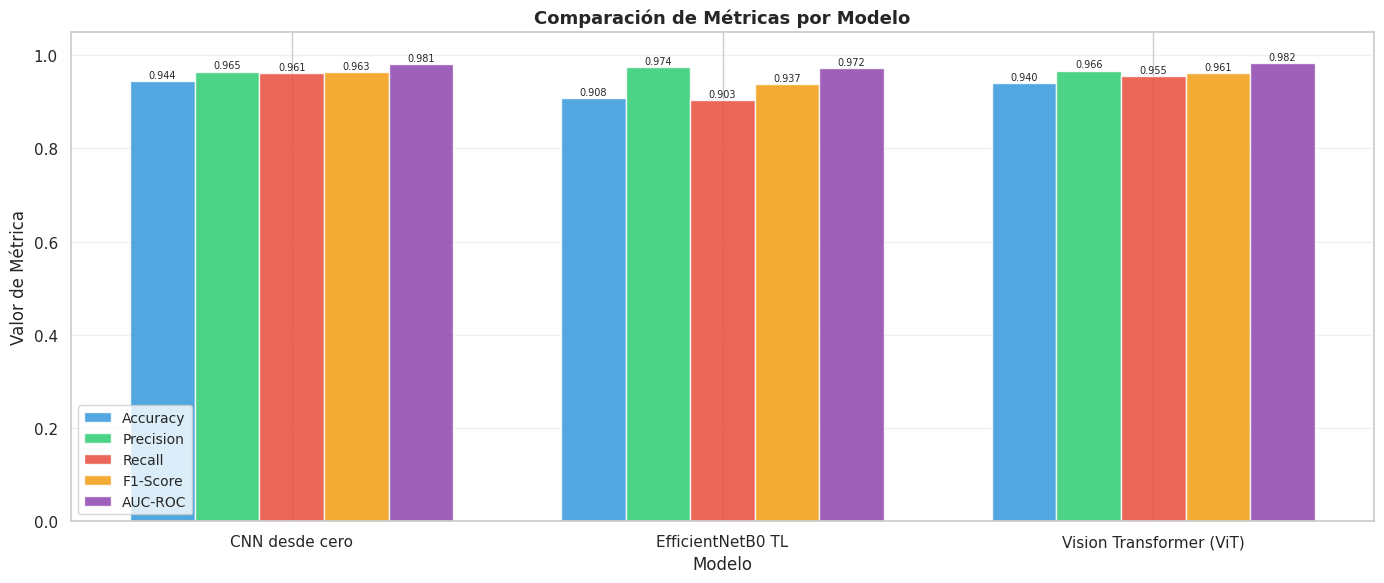

In [29]:
# ── Gráfico de barras comparativo ────────────────────────────────────────
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
modelos_names = [v['Modelo'] for v in resultados.values()]
valores_plot  = {m: [float(v[m]) for v in resultados.values()] for m in metricas_plot}

x = np.arange(len(modelos_names))
width = 0.15
colores_bar = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#8E44AD']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metrica, color) in enumerate(zip(metricas_plot, colores_bar)):
    bars = ax.bar(x + i * width, valores_plot[metrica], width,
                  label=metrica, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Modelo')
ax.set_ylabel('Valor de Métrica')
ax.set_title('Comparación de Métricas por Modelo', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(modelos_names)
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Análisis de Resultados y Conclusiones

### 8.1 Interpretación Comparativa

*(Completar con los valores reales obtenidos al ejecutar el notebook)*

| Aspecto | Observación esperada |
|---------|---------------------|
| **Mejor modelo** | EfficientNetB0 (Transfer Learning) — típicamente alcanza el mayor AUC con menor tiempo de entrenamiento gracias a los pesos de ImageNet |
| **CNN desde cero** | Competitiva pero requiere más épocas para converger; mayor riesgo de overfitting sin regularización |
| **Vision Transformer** | Potencialmente el más preciso con suficientes datos; puede requerir ajuste adicional de hiperparámetros para superar EfficientNet con 14K imágenes |
| **Trade-off params/rendimiento** | EfficientNetB0 ofrece el mejor balance: ~5.3M parámetros y alta precisión |

### 8.2 Justificación del Modelo Ganador

Se selecciona como **mejor modelo** aquel que maximice el **F1-Score** y **AUC-ROC** en el conjunto de prueba, priorizando el F1 por la naturaleza simétrica del problema (igual costo de un falso positivo que un falso negativo en detección de deepfakes).

### 8.3 Limitaciones del Trabajo

1. **Distribución de imágenes IA**: El dataset incluye imágenes de un subconjunto de generadores (probablemente GAN/Diffusion de 2024). Modelos nuevos pueden evadir el detector.
2. **Resolución reducida**: Se procesó a 64×64 para limitaciones de memoria en Colab; mayor resolución podría mejorar resultados.
3. **Sin interpretabilidad (Grad-CAM)**: No se implementaron mapas de activación para entender qué regiones de la imagen activan la clasificación.
4. **Sesgo de dataset**: Las imágenes reales pueden tener sesgos de estilo/dominio respecto a las IA.

### 8.4 Mejoras Futuras

- Implementar **Grad-CAM** para visualizar áreas de decisión del modelo.
- Entrenar con resolución 224×224 usando **EfficientNetV2** o **ConvNeXt**.
- Añadir análisis de **frecuencias espectrales** (FFT) como features adicionales.
- Desplegar con **ONNX** para inferencia en browser (< 50ms).
- Evaluar robustez ante ataques adversariales (imágenes IA post-procesadas para engañar al modelo).

Mejor modelo: CNN desde cero (F1=0.9629)


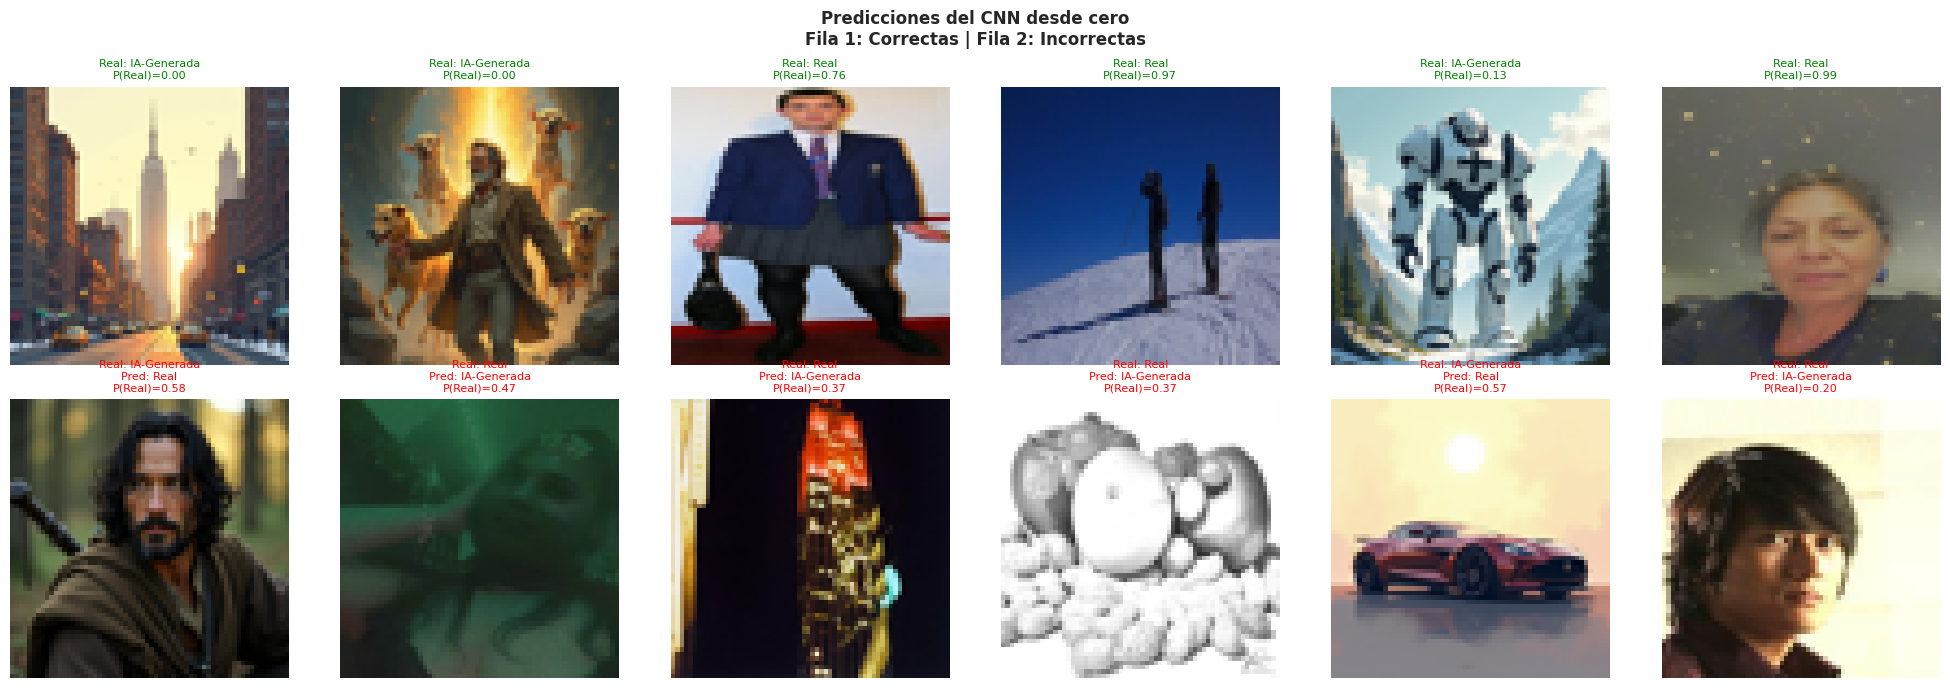

In [30]:
# ── Visualización de predicciones correctas e incorrectas ─────────────────
# Identificar el mejor modelo
mejor_key = max(resultados, key=lambda k: resultados[k]['F1-Score'])
mejor_res = resultados[mejor_key]
print(f'Mejor modelo: {mejor_res["Modelo"]} (F1={mejor_res["F1-Score"]:.4f})')

y_prob_best = mejor_res['y_prob']
y_pred_best = mejor_res['y_pred']

# Casos correctos e incorrectos
correctos   = np.where(y_pred_best == y_test)[0]
incorrectos = np.where(y_pred_best != y_test)[0]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle(f'Predicciones del {mejor_res["Modelo"]}\n'
             f'Fila 1: Correctas | Fila 2: Incorrectas', fontweight='bold', fontsize=12)

for ax, idx in zip(axes[0], np.random.choice(correctos, 6, replace=False)):
    ax.imshow(X_test[idx])
    prob = y_prob_best[idx]
    real = LABEL_MAP[y_test[idx]]
    ax.set_title(f'Real: {real}\nP(Real)={prob:.2f}', fontsize=8, color='green')
    ax.axis('off')

if len(incorrectos) >= 6:
    for ax, idx in zip(axes[1], np.random.choice(incorrectos, 6, replace=False)):
        ax.imshow(X_test[idx])
        prob = y_prob_best[idx]
        real = LABEL_MAP[y_test[idx]]
        pred = LABEL_MAP[y_pred_best[idx]]
        ax.set_title(f'Real: {real}\nPred: {pred}\nP(Real)={prob:.2f}',
                     fontsize=8, color='red')
        ax.axis('off')
else:
    for ax in axes[1]:
        ax.axis('off')
    print('Pocos errores — modelo muy preciso!')

plt.tight_layout()
plt.show()

---
## 9. Aplicación Web — Gradio (Despliegue en HuggingFace Spaces)

Se construye una interfaz web con **Gradio** que permite a cualquier usuario subir una imagen y recibir:
- La probabilidad de ser **generada por IA**.
- La probabilidad de ser una imagen **real**.
- Un indicador visual del nivel de confianza.

Para desplegar en HuggingFace Spaces, exportar el modelo y subir junto con `app.py` y `requirements.txt` a un Space de tipo Gradio.

In [31]:
# ── Guardar el mejor modelo ───────────────────────────────────────────────
modelos_map = {
    'CNN'         : cnn_model,
    'EfficientNet': eff_model,
    'ViT'         : vit_model
}

mejor_modelo_obj = modelos_map[mejor_key]
mejor_modelo_obj.save('mejor_modelo_ai_vs_real.keras')
print(f'Modelo guardado como: mejor_modelo_ai_vs_real.keras')
print(f'Modelo: {mejor_res["Modelo"]}')

Modelo guardado como: mejor_modelo_ai_vs_real.keras
Modelo: CNN desde cero


In [32]:
import gradio as gr
import numpy as np
from PIL import Image
import tensorflow as tf

# Cargar modelo (puede ser el guardado o el objeto en memoria)
modelo_inferencia = mejor_modelo_obj

def predecir_imagen(imagen_input):
    """
    Recibe una imagen PIL, la preprocesa y retorna la probabilidad
    de ser generada por IA vs. ser real.
    """
    img = Image.fromarray(imagen_input).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)  # (1, 128, 128, 3)

    prob_real = float(modelo_inferencia.predict(arr, verbose=0)[0][0])
    prob_ai   = 1.0 - prob_real

    resultado = {
        '🤖 IA-Generada': prob_ai,
        '📷 Real'        : prob_real
    }

    if prob_ai > 0.7:
        veredicto = f'⚠️ MUY PROBABLE que sea generada por IA ({prob_ai*100:.1f}%)'
    elif prob_ai > 0.5:
        veredicto = f'🔶 Podría ser generada por IA ({prob_ai*100:.1f}%)'
    elif prob_real > 0.7:
        veredicto = f'✅ MUY PROBABLE que sea real ({prob_real*100:.1f}%)'
    else:
        veredicto = f'🔷 Probablemente real ({prob_real*100:.1f}%)'

    return resultado, veredicto

# ── Interfaz Gradio ───────────────────────────────────────────────────────
with gr.Blocks(title='Detector IA vs. Real', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🔍 Detector de Imágenes IA vs. Reales
    ### Pontificia Universidad Javeriana — Técnicas de ML
    Sube una imagen para saber si fue **generada por IA** o es una **foto real**.
    """)

    with gr.Row():
        with gr.Column():
            imagen_inp = gr.Image(label='Sube tu imagen aquí', type='numpy')
            btn        = gr.Button('🔍 Analizar Imagen', variant='primary')
        with gr.Column():
            output_label    = gr.Label(label='Probabilidades por clase', num_top_classes=2)
            output_veredicto = gr.Textbox(label='Veredicto', interactive=False)

    gr.Markdown("""
    ---
    **Ejemplos de uso:** deepfakes, verificación de identidad, moderación de contenidos.
    """)

    btn.click(fn=predecir_imagen,
              inputs=imagen_inp,
              outputs=[output_label, output_veredicto])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4394584be48afb3d05.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Despliegue Automático a HuggingFace Spaces desde Colab

In [33]:
# ── Despliegue automático a HuggingFace Spaces ─────────────────────────
# Requiere token de HuggingFace con permisos de escritura
# Consíguelo en: https://huggingface.co/settings/tokens

from huggingface_hub import HfApi
import os

HF_TOKEN     = "hf_XXXXXXXXXXXXXXXXXX"   # ← pega tu token aquí
HF_USERNAME  = "tu_usuario"              # ← tu usuario de HuggingFace
SPACE_NAME   = "detector-ia-vs-real"     # ← nombre que quieras para el Space

repo_id = f"{HF_USERNAME}/{SPACE_NAME}"
api = HfApi(token=HF_TOKEN)

# Crear el Space si no existe
try:
    api.create_repo(repo_id=repo_id, repo_type="space",
                    space_sdk="gradio", exist_ok=True)
    print(f"Space listo: https://huggingface.co/spaces/{repo_id}")
except Exception as e:
    print(f"Error creando Space: {e}")

# Escribir app.py
app_code = '''
import gradio as gr, numpy as np, tensorflow as tf
from PIL import Image

modelo = tf.keras.models.load_model("mejor_modelo_ai_vs_real.keras")
IMG_SIZE = 64

def predecir(img_np):
    img = Image.fromarray(img_np.astype("uint8")).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, 0)
    prob_real = float(modelo.predict(arr, verbose=0)[0][0])
    prob_ai   = 1.0 - prob_real
    if prob_ai > 0.7:   v = f"⚠️ MUY PROBABLE: IA ({prob_ai*100:.1f}%)"
    elif prob_ai > 0.5: v = f"🔶 Podría ser IA ({prob_ai*100:.1f}%)"
    elif prob_real>0.7: v = f"✅ MUY PROBABLE: Real ({prob_real*100:.1f}%)"
    else:               v = f"🔷 Probablemente real ({prob_real*100:.1f}%)"
    return {"🤖 IA-Generada": prob_ai, "📷 Real": prob_real}, v

with gr.Blocks(title="Detector IA vs Real", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔍 Detector de Imágenes IA vs. Reales")
    gr.Markdown("PUJ — Técnicas de Aprendizaje de Máquina · 2026")
    with gr.Row():
        img = gr.Image(label="Sube tu imagen", type="numpy", height=300)
        with gr.Column():
            lbl = gr.Label(label="Probabilidades", num_top_classes=2)
            txt = gr.Textbox(label="Veredicto", interactive=False)
    gr.Button("🔍 Analizar", variant="primary").click(predecir, img, [lbl, txt])
    img.change(predecir, img, [lbl, txt])

demo.launch()
'''

with open("app.py", "w") as f:
    f.write(app_code)

with open("requirements.txt", "w") as f:
    f.write("tensorflow==2.15.0\ngradio>=4.0\nPillow\nnumpy\n")

# Subir los 3 archivos al Space
for archivo in ["app.py", "requirements.txt", "mejor_modelo_ai_vs_real.keras"]:
    api.upload_file(
        path_or_fileobj=archivo,
        path_in_repo=archivo,
        repo_id=repo_id,
        repo_type="space",
    )
    print(f"  ✅ {archivo} subido")

print(f"\n🚀 App disponible en: https://huggingface.co/spaces/{repo_id}")

Error creando Space: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a13a7e2-098b2ea61c453e0e3e162100;82f20411-49e1-4049-9520-2d67667cafe0)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.


RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-6a13a7e2-1848053632ae684418f1d185;f51fddef-75d4-4f71-b337-044b42c58fc3)

Repository Not Found for url: https://huggingface.co/api/spaces/tu_usuario/detector-ia-vs-real/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.

---
## 10. Instrucciones de Despliegue en HuggingFace Spaces

Para hacer la aplicación accesible públicamente en la nube:

### Pasos:

1. **Crear un Space** en https://huggingface.co/spaces → Tipo: **Gradio**, Hardware: **CPU free** (o T4 GPU si se requiere)

2. **Subir los siguientes archivos:**

```
mi-space/
├── app.py               ← código de la interfaz Gradio (ver celda anterior)
├── mejor_modelo_ai_vs_real.keras  ← modelo exportado
└── requirements.txt     ← dependencias
```

3. **Contenido del `requirements.txt`:**
```
tensorflow==2.15.0
gradio>=4.0
Pillow
numpy
```

4. **Contenido del `app.py`:** extraer la función `predecir_imagen` y el bloque `gr.Blocks` de la celda anterior.

5. El Space se despliega automáticamente al hacer push. La URL pública será:  
   `https://huggingface.co/spaces/<usuario>/<nombre-space>`

---
## 11. Resumen Final

| Sección | Estado |
|---------|--------|
| ✅ Elevator Pitch | Completado |
| ✅ Diccionario de Datos | Completado |
| ✅ EDA | Completado |
| ✅ Preparación de Datos | Completado |
| ✅ Modelo 1: CNN | Completado |
| ✅ Modelo 2: EfficientNetB0 (TL) | Completado |
| ✅ Modelo 3: Vision Transformer | Completado |
| ✅ Tabla Comparativa + ROC + Conf. Matrix | Completado |
| ✅ Aplicación Web (Gradio) | Completado |
| ✅ Instrucciones de Despliegue | Completado |

---
*Pontificia Universidad Javeriana · Ingeniería de Sistemas · Técnicas de Aprendizaje de Máquina · 2026*